In [1]:
ON_COLAB = True
USE_DRIVE = False

In [2]:
if ON_COLAB:
    # ----- for colab
    from zipfile import ZipFile
    !gdown 1TkdWr42pf3BN02xW9diBcldNsC7NYpNd
    !gdown 1ScJ0sAt01sQdVXA7wHZuvmkf7fXhU5Zq
    with ZipFile("images.zip", 'r') as zObject:
        zObject.extractall(path="dataset")

    with ZipFile("annotations.zip", 'r') as zObject:
        zObject.extractall(path="dataset")

Downloading...
From (original): https://drive.google.com/uc?id=1TkdWr42pf3BN02xW9diBcldNsC7NYpNd
From (redirected): https://drive.google.com/uc?id=1TkdWr42pf3BN02xW9diBcldNsC7NYpNd&confirm=t&uuid=8bc3eab9-9c3e-440d-acbd-77285f33fc5c
To: /content/images.zip
100% 792M/792M [00:11<00:00, 70.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ScJ0sAt01sQdVXA7wHZuvmkf7fXhU5Zq
To: /content/annotations.zip
100% 18.5k/18.5k [00:00<00:00, 63.9MB/s]


In [3]:
from pathlib import Path
from PIL import Image
from torch import Tensor
from torch.utils.data import Dataset
from typing import List, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import time

import matplotlib.pyplot as plt


In [4]:
class OxfordPetDataset(Dataset):
    def __init__(self, split: str, transform=None) -> None:
        super().__init__()

        if USE_DRIVE:
            self.root = Path("drive") / "MyDrive" / "Colab Notebooks" / "cv" / "dataset"
        elif ON_COLAB:
            self.root = Path("dataset")
        else:
            self.root = Path("/home/liam/Desktop/magistrale/computervision/progetto/modulo_due/ipcv-assignment-2/dataset")
        self.split = split
        self.names, self.labels = self._get_names_and_labels()
        self.transform = transform

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx) -> Tuple[Tensor, int]:
        img_path = self.root / "images" / f"{self.names[idx]}.jpg"
        img = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

    def get_num_classes(self) -> int:
        return max(self.labels) + 1

    def _get_names_and_labels(self) -> Tuple[List[str], List[int]]:
        names = []
        labels = []

        with open(self.root / "annotations" / f"{self.split}.txt") as f:
            for line in f:
                name, label = line.replace("\n", "").split(" ")
                names.append(name),
                labels.append(int(label) - 1)

        return names, labels

In [5]:
import random
from torchvision import transforms
from torchvision.transforms import functional as tF
from torchvision.transforms import RandomPerspective


class Random90DegreeRotation:
    """Custom transform for 90-degree rotations with specific probabilities."""
    def __call__(self, img):
        prob = random.random()
        if prob < 0.5:
            return img  # no rotation
        elif prob < 0.75:
            return tF.rotate(img, angle=-90)
        else:
            return tF.rotate(img, angle=90)

class OuterRandomCrop:
    """Custom transform to randomly crop the same amount of pixels from each side of the image."""
    def __init__(self, max_pixels_to_crop):
        """
        Args:
            max_pixels_to_crop (int): The maximum number of pixels to subtract from each side of the image.
        """
        self.max_pixels_to_crop = max_pixels_to_crop

    def __call__(self, img):
        # decides whether to apply the crop (75% chance)
        if random.random() < 0.25:
            return img

        # randomly select the number of pixels to crop (between 0 and max_pixels_to_crop)
        pixels_to_crop = random.randint(0, self.max_pixels_to_crop)

        width, height = img.size
        crop_left = pixels_to_crop
        crop_top = pixels_to_crop
        crop_width = width - 2 * pixels_to_crop
        crop_height = height - 2 * pixels_to_crop

        if crop_width <= 0 or crop_height <= 0:
            raise ValueError("The number of pixels to crop is too large for the image dimensions.")

        return tF.crop(img, top=crop_top, left=crop_left, height=crop_height, width=crop_width)



convert_compatible = transforms.Compose([
    transforms.Resize((224, 224)),     # Deterministic resize
    transforms.ToTensor(),             # Format conversion only
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # image net normalization values
])

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_data_augmentation = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.2)
])

# Create datasets
train_dataset = OxfordPetDataset('train', transform=transform_data_augmentation)
val_dataset = OxfordPetDataset('val', transform=convert_compatible)
test_dataset = OxfordPetDataset('test', transform=convert_compatible)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

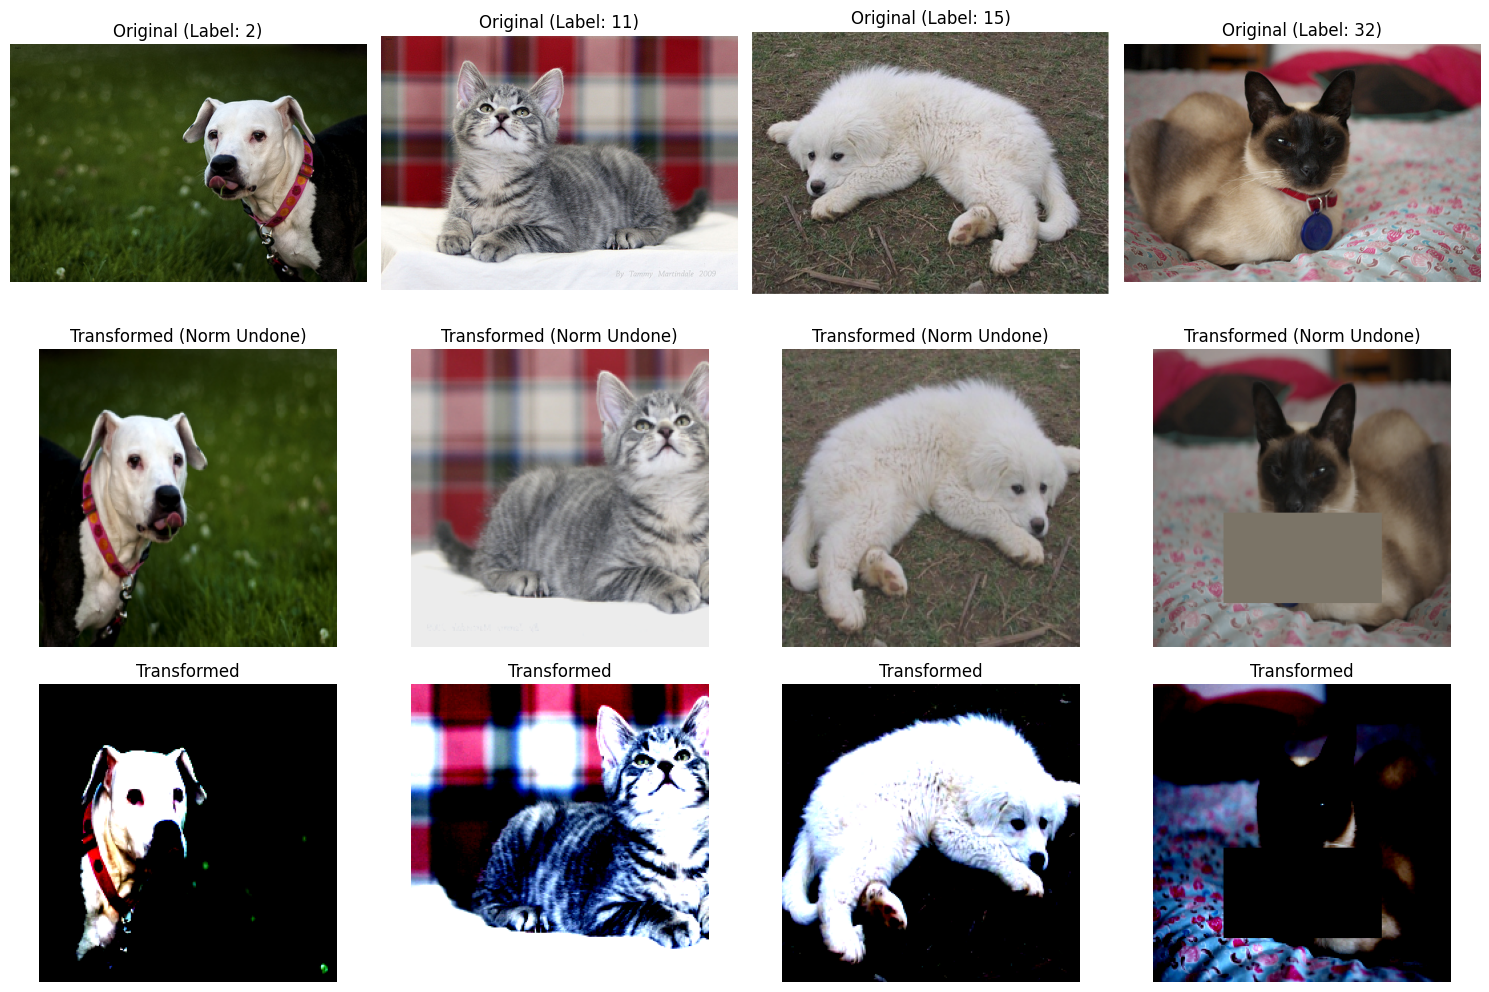

In [6]:
import matplotlib.pyplot as plt
import random

# Function to display images
def display_image_comparison(dataset, num_images=4):
    fig, axes = plt.subplots(3, num_images, figsize=(15, 10))  # 3 rows, num_images columns

    for i in range(num_images):
        # Randomly select an image from the dataset
        idx = random.randint(0, len(dataset) - 1)

        # Access the raw image without applying the dataset's transform
        img_path = dataset.root / "images" / f"{dataset.names[idx]}.jpg"
        original_img = Image.open(img_path).convert("RGB")  # Load as PIL image
        label = dataset.labels[idx]

        # Apply your transformation
        transformed_with_norm = transform_data_augmentation(original_img)  # Fully transformed with normalization

        # Undo normalization for visualization
        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.224, 0.225]
        transformed_with_norm_np = transformed_with_norm.permute(1, 2, 0).numpy()
        transformed_no_norm_np = std * transformed_with_norm_np + mean  # Undo normalization
        transformed_no_norm_np = transformed_no_norm_np.clip(0, 1)

        # Display original image
        axes[0, i].imshow(original_img)
        axes[0, i].set_title(f"Original (Label: {label})")
        axes[0, i].axis("off")

        # Display transformed image with normalization undone
        axes[1, i].imshow(transformed_no_norm_np)
        axes[1, i].set_title("Transformed (Norm Undone)")
        axes[1, i].axis("off")

        # Display fully transformed image (with normalization)
        axes[2, i].imshow(transformed_with_norm_np)
        axes[2, i].set_title("Transformed")
        axes[2, i].axis("off")

    plt.tight_layout()
    plt.show()

# Call the function to display the comparison
display_image_comparison(train_dataset, num_images=4)

ho tolto mixup e cutmix

ho tolto "num_workers" dal TrainConfig che non veniva usato

ho tolto batch_size e la funzione one_hot e soft_cross_entropy perchè senza mixup e cutmix non venivano usati

(copilot): *EMA: nel tuo codice non influisce sull’addestramento perché non viene usato per validazione/salvataggio; puoi rimuoverlo*. ho rimosso anche la funzione deep_copy_model

ho tolto anche accuracy_top1 non veniva usata

ho impostato amp a false

ho tolto il label smoothing

IMPORTANTE: provo con la mia funzione di training. mi sembra che la differenza più grossa sia lo scheduler onecyclelr quindi metto quello

una cosa che manca è il clip dei pesi, che non ho messo qua

In [7]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=10,
    one_cycle_max_lr = 4e-3,
    show_all_minibatches_loss=False
):
    """
    Trains a PyTorch model and evaluates it on a validation set.

    Args:
        model (torch.nn.Module): The model to train.
        train_loader (DataLoader): DataLoader for the training dataset.
        val_loader (DataLoader): DataLoader for the validation dataset.
        criterion (torch.nn.Module): Loss function to optimize.
        optimizer (torch.optim.Optimizer): Optimizer for updating model weights.
        num_epochs (int): Number of epochs to train the model.
        show_all_minibatches_loss (bool): Can be 'no', 'brief', 'verbose'. Determines how many mini batch losses are printed

    Returns:
        tuple: A tuple containing:
            - train_losses (list): List of average training losses per epoch.
            - train_accuracies (list): List of training accuracies per epoch.
            - train_class_accuracies (list): List of per-class training accuracies per epoch.
            - val_losses (list): List of validation losses per epoch.
            - val_accuracies (list): List of validation accuracies per epoch.
            - val_class_accuracies (list): List of per-class validation accuracies per epoch.
            - train_epoch_times (list): Tempo (s) della sola fase di training per epoca.
            - total_epoch_times (list): Tempo (s) dell’intero ciclo per epoca (train + validazione/metriche).
    """

    train_losses = []
    train_accuracies = []
    train_class_accuracies = []
    val_losses = []
    val_accuracies = []
    val_class_accuracies = []
    train_epoch_times = []
    total_epoch_times = []

    # Get number of classes from the model's output layer
    num_classes = model.fc.out_features

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Setup OneCycleLR scheduler (per-batch). Uses current optimizer lr as max_lr.
    try:
        steps_per_epoch = len(train_loader)
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=one_cycle_max_lr, epochs=num_epochs, steps_per_epoch=steps_per_epoch
        )
        scheduler_per_batch = True
    except Exception:
        scheduler = None
        scheduler_per_batch = False

    for epoch in range(num_epochs):
        t_epoch_start = time.time()

        # --- Training phase ---
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        train_class_correct = torch.zeros(num_classes, dtype=torch.long)
        train_class_total = torch.zeros(num_classes, dtype=torch.long)

        tot_batches = train_loader.__len__()
        t_train_start = time.time()
        for batch_idx, (batch_images, batch_labels) in enumerate(train_loader):
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)

            # Zero gradients from previous iteration
            optimizer.zero_grad()

            outputs = model(batch_images)
            loss = criterion(outputs, batch_labels)
            if show_all_minibatches_loss != 'no':
                if show_all_minibatches_loss == 'verbose' or batch_idx in [40, 80]:
                    print(f"Batch {batch_idx + 1}/{tot_batches}: loss = {loss.item():.4f}")

            # Compute gradients
            loss.backward()

            # Update weights
            optimizer.step()

            # Step scheduler per-batch (if configured)
            if scheduler_per_batch and scheduler is not None:
                scheduler.step()

            running_loss += loss.item()

            # Calculate training accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_train += batch_labels.size(0)
            correct_train += (predicted == batch_labels).sum().item()

            # Per-class accuracy for training
            for i in range(batch_labels.size(0)):
                label = batch_labels[i]
                train_class_total[label] += 1
                if predicted[i] == label:
                    train_class_correct[label] += 1

        # Time
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        train_time = time.time() - t_train_start
        train_epoch_times.append(train_time)

        train_accuracy = 100 * correct_train / total_train
        train_loss = running_loss / len(train_loader)

        # Training Per-Class Accuracies
        epoch_train_class_accuracies = []
        for i in range(num_classes):
            if train_class_total[i] > 0:
                class_acc = train_class_correct[i].item() / train_class_total[i].item()
            else:
                class_acc = 0.0  # no samples for this class
            epoch_train_class_accuracies.append(class_acc)

        # --- Validation ---
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        # Initialize per-class counters for validation
        val_class_correct = torch.zeros(num_classes, dtype=torch.long)
        val_class_total = torch.zeros(num_classes, dtype=torch.long)

        with torch.no_grad():  # don't compute gradients for validation
            for batch_images, batch_labels in val_loader:
                batch_images = batch_images.to(device)
                batch_labels = batch_labels.to(device)

                outputs = model(batch_images)
                loss = criterion(outputs, batch_labels)
                running_val_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total_val += batch_labels.size(0)
                correct_val += (predicted == batch_labels).sum().item()

                # Validation Per-Class Accuracies
                for i in range(batch_labels.size(0)):
                    label = batch_labels[i]
                    val_class_total[label] += 1
                    if predicted[i] == label:
                        val_class_correct[label] += 1

        val_accuracy = 100 * correct_val / total_val
        val_loss = running_val_loss / len(val_loader)

        # Validation Per-Class Accuracies
        epoch_val_class_accuracies = []
        for i in range(num_classes):
            if val_class_total[i] > 0:
                class_acc = val_class_correct[i].item() / val_class_total[i].item()
            else:
                class_acc = 0.0  # no samples for this class
            epoch_val_class_accuracies.append(class_acc)

        # Time
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        total_time = time.time() - t_epoch_start
        total_epoch_times.append(total_time)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        train_class_accuracies.append(epoch_train_class_accuracies)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        val_class_accuracies.append(epoch_val_class_accuracies)

        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}% | "
              f"Epoch Time: {total_time:.2f}s")

        print('-'*20)

    return (train_losses, train_accuracies, train_class_accuracies,
            val_losses, val_accuracies, val_class_accuracies,
            train_epoch_times, total_epoch_times)

# resnet model

In [8]:
import torch
import math
import torch.nn as nn

class BasicConv(nn.Module):
    def __init__(self, in_planes, out_planes, kernel_size, stride=1, padding=0, dilation=1, groups=1, relu=True, bn=True, bias=False):
        super(BasicConv, self).__init__()
        self.out_channels = out_planes
        self.conv = nn.Conv2d(in_planes, out_planes, kernel_size=kernel_size, stride=stride, padding=padding, dilation=dilation, groups=groups, bias=bias)
        self.bn = nn.BatchNorm2d(out_planes,eps=1e-5, momentum=0.01, affine=True) if bn else None
        self.relu = nn.ReLU() if relu else None

    def forward(self, x):
        x = self.conv(x)
        if self.bn is not None:
            x = self.bn(x)
        if self.relu is not None:
            x = self.relu(x)
        return x

class Flatten(nn.Module):
    def forward(self, x):
        return x.view(x.size(0), -1)

class ChannelGate(nn.Module):
    def __init__(self, gate_channels, reduction_ratio=16, pool_types=['avg', 'max']):
        super(ChannelGate, self).__init__()
        self.gate_channels = gate_channels
        self.mlp = nn.Sequential(
            Flatten(),
            nn.Linear(gate_channels, gate_channels // reduction_ratio),
            nn.ReLU(),
            nn.Linear(gate_channels // reduction_ratio, gate_channels)
            )
        self.pool_types = pool_types
    def forward(self, x):
        channel_att_sum = None
        for pool_type in self.pool_types:
            if pool_type=='avg':
                avg_pool = F.avg_pool2d( x, (x.size(2), x.size(3)), stride=(x.size(2), x.size(3)))
                channel_att_raw = self.mlp( avg_pool )
            elif pool_type=='max':
                max_pool = F.max_pool2d( x, (x.size(2), x.size(3)), stride=(x.size(2), x.size(3)))
                channel_att_raw = self.mlp( max_pool )

            if channel_att_sum is None:
                channel_att_sum = channel_att_raw
            else:
                channel_att_sum = channel_att_sum + channel_att_raw

        scale = torch.sigmoid( channel_att_sum ).unsqueeze(2).unsqueeze(3).expand_as(x)
        return x * scale

def logsumexp_2d(tensor):
    tensor_flatten = tensor.view(tensor.size(0), tensor.size(1), -1)
    s, _ = torch.max(tensor_flatten, dim=2, keepdim=True)
    outputs = s + (tensor_flatten - s).exp().sum(dim=2, keepdim=True).log()
    return outputs

class ChannelPool(nn.Module):
    def forward(self, x):
        return torch.cat( (torch.max(x,1)[0].unsqueeze(1), torch.mean(x,1).unsqueeze(1)), dim=1 )

class SpatialGate(nn.Module):
    def __init__(self):
        super(SpatialGate, self).__init__()
        kernel_size = 7
        self.compress = ChannelPool()
        self.spatial = BasicConv(2, 1, kernel_size, stride=1, padding=(kernel_size-1) // 2, relu=False)
    def forward(self, x):
        x_compress = self.compress(x)
        x_out = self.spatial(x_compress)
        scale = torch.sigmoid(x_out) # broadcasting
        return x * scale

class CBAM(nn.Module):
    def __init__(self, gate_channels, reduction_ratio=16, pool_types=['avg', 'max'], no_spatial=False): # no_spatial is normally set to false
        super(CBAM, self).__init__()
        self.ChannelGate = ChannelGate(gate_channels, reduction_ratio, pool_types)
        self.no_spatial=no_spatial
        if not no_spatial:
            self.SpatialGate = SpatialGate()
    def forward(self, x):
        x_out = self.ChannelGate(x)
        if not self.no_spatial:
            x_out = self.SpatialGate(x_out)
        return x_out


class BasicBlock(nn.Module):
    """A basic residual block for ResNet."""
    def __init__(self, in_channels, out_channels, stride=1, downsample=None, use_cbam=True):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
        self.use_cbam = use_cbam
        if use_cbam:
          self.cbam = CBAM(out_channels, reduction_ratio=8)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.use_cbam:
          out = self.cbam(out)

        if self.downsample is not None:
          identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out


class ResNet(nn.Module):
    """Custom ResNet architecture."""
    def __init__(self, block, layers, num_classes=37,
            base_widths=(24, 48, 96, 192), cbam_stages=(False, False, True, True)):
        super(ResNet, self).__init__()
        self.in_channels = 24
        c1, c2, c3, c4 = base_widths

        self.stem = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c1, c1, kernel_size=3, stride=2, padding=1, bias=False),  # downsample qui
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True),
        )

        # Residual layers
        self.layer1 = self._make_layer(block, c1, layers[0], use_cbam=cbam_stages[0])
        self.layer2 = self._make_layer(block, c2, layers[1], stride=2, use_cbam=cbam_stages[1])
        self.layer3 = self._make_layer(block, c3, layers[2], stride=2, use_cbam=cbam_stages[2])
        self.layer4 = self._make_layer(block, c4, layers[3], stride=2, use_cbam=cbam_stages[3])

        # Fully connected layer
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(c4, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1, use_cbam=True):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample, use_cbam=use_cbam))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(block(out_channels, out_channels, use_cbam=use_cbam))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)

        return x


def resnet18(num_classes=37):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes=num_classes)


num_classes = 37
model_resnet = resnet18(num_classes=num_classes)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_resnet = model_resnet.to(device)


from torchsummary import summary
summary(model_resnet, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 24, 224, 224]             648
       BatchNorm2d-2         [-1, 24, 224, 224]              48
              ReLU-3         [-1, 24, 224, 224]               0
            Conv2d-4         [-1, 24, 112, 112]           5,184
       BatchNorm2d-5         [-1, 24, 112, 112]              48
              ReLU-6         [-1, 24, 112, 112]               0
            Conv2d-7         [-1, 24, 112, 112]           5,184
       BatchNorm2d-8         [-1, 24, 112, 112]              48
              ReLU-9         [-1, 24, 112, 112]               0
           Conv2d-10         [-1, 24, 112, 112]           5,184
      BatchNorm2d-11         [-1, 24, 112, 112]              48
             ReLU-12         [-1, 24, 112, 112]               0
       BasicBlock-13         [-1, 24, 112, 112]               0
           Conv2d-14         [-1, 24, 1

In [9]:
lr = 3e-4
one_cycle_max_lr = 4e-3
weight_decay = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_resnet.parameters(), lr=lr, weight_decay=weight_decay)

train_losses, train_accuracies, train_class_accuracies, val_losses, val_accuracies, val_class_accuracies, train_epoch_times, total_epoch_times = train_model(
    model_resnet, train_loader, val_loader, criterion, optimizer, num_epochs=80,
    one_cycle_max_lr=one_cycle_max_lr, show_all_minibatches_loss='no'
)

Epoch [1/80], Train Loss: 3.5648, Train Acc: 4.99%, Val Loss: 3.5179, Val Acc: 5.78% | Epoch Time: 54.85s
--------------------
Epoch [2/80], Train Loss: 3.4307, Train Acc: 8.04%, Val Loss: 3.5021, Val Acc: 7.14% | Epoch Time: 55.69s
--------------------
Epoch [3/80], Train Loss: 3.3521, Train Acc: 9.35%, Val Loss: 3.4620, Val Acc: 7.69% | Epoch Time: 54.65s
--------------------
Epoch [4/80], Train Loss: 3.2679, Train Acc: 10.08%, Val Loss: 3.9551, Val Acc: 6.11% | Epoch Time: 54.73s
--------------------
Epoch [5/80], Train Loss: 3.1799, Train Acc: 11.99%, Val Loss: 3.3154, Val Acc: 10.09% | Epoch Time: 55.23s
--------------------
Epoch [6/80], Train Loss: 3.0734, Train Acc: 15.37%, Val Loss: 3.3601, Val Acc: 11.18% | Epoch Time: 54.30s
--------------------
Epoch [7/80], Train Loss: 2.9754, Train Acc: 16.52%, Val Loss: 3.7558, Val Acc: 8.72% | Epoch Time: 55.07s
--------------------
Epoch [8/80], Train Loss: 2.8585, Train Acc: 20.03%, Val Loss: 3.0750, Val Acc: 14.78% | Epoch Time: 54.3

In [10]:

def get_preds_and_trues(model, dataset, batch_size=32, device=None):
    """
    Return (y_true, y_pred) as 1-D numpy arrays (dtype=int) suitable for sklearn.metrics.confusion_matrix.

    Args:
        model (torch.nn.Module): model with loaded weights (will be moved to `device`).
        dataset (torch.utils.data.Dataset): dataset that yields (input, label) pairs.
        batch_size (int): batch size used to create an internal DataLoader (shuffle=False).
        device (torch.device or None): device for inference; if None, inferred from the model.

    Returns:
        (y_true, y_pred): two 1-D numpy arrays of integer labels with the same length.
    """
    import numpy as np
    import torch
    from torch.utils.data import DataLoader

    device = device or (next(model.parameters()).device if any(True for _ in model.parameters()) else torch.device('cpu'))
    model = model.to(device)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    model.eval()
    all_true = []
    all_pred = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1).cpu().numpy()

            # yb can be torch.Tensor or list/np.array
            if isinstance(yb, torch.Tensor):
                y_np = yb.cpu().numpy()
            else:
                import numpy as _np
                y_np = _np.asarray(yb)

            all_true.append(y_np)
            all_pred.append(preds)

    if len(all_true) == 0:
        return np.array([], dtype=int), np.array([], dtype=int)

    y_true = np.concatenate(all_true).ravel().astype(int)
    y_pred = np.concatenate(all_pred).ravel().astype(int)

    # sanity check: stessa lunghezza
    if y_true.shape[0] != y_pred.shape[0]:
        raise ValueError(f"Mismatch lengths: y_true={y_true.shape[0]} y_pred={y_pred.shape[0]}")

    return y_true, y_pred

In [11]:
import os
import pickle

output_dir = "results"

os.makedirs(output_dir, exist_ok=True)

y_true, y_pred = get_preds_and_trues(model_resnet, test_dataset, device=device)

history = {}
history['train_loss'] = train_losses
history['train_acc'] = train_accuracies
history['train_class_acc'] = train_class_accuracies
history['val_loss'] = val_losses
history['val_acc'] = val_accuracies
history['val_class_acc'] = val_class_accuracies
history['train_epoch_times'] = train_epoch_times
history['total_epoch_times'] = total_epoch_times
history['y_pred'] = y_pred
history['y_true'] = y_true

with open(os.path.join(output_dir, "history.pkl"), "wb") as f:
    pickle.dump(history, f)


torch.save(model_resnet, "resnet_18_complete_training_weights")

## losses and accuracies

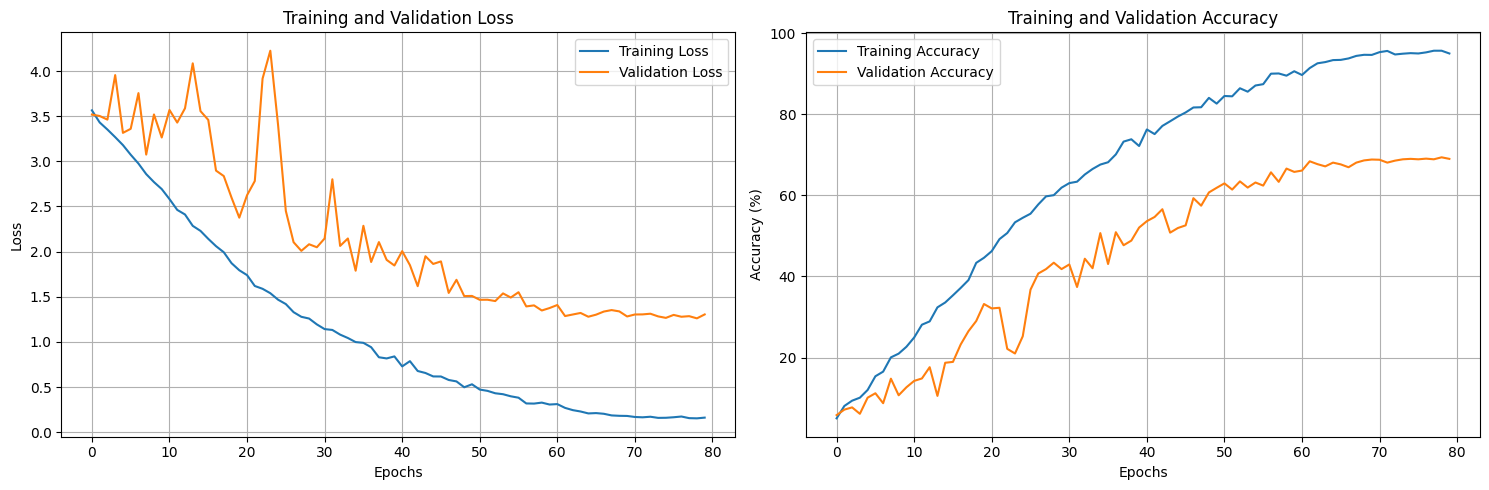

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history['train_loss'], label='Training Loss')
axes[0].plot(history['val_loss'], label='Validation Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Training Accuracy')
axes[1].plot(history['val_acc'], label='Validation Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Test set accuracy

In [13]:
# Load the saved model weights and map them to the CPU
# model_resnet.load_state_dict(torch.load("resnet_18_complete_training_weights", map_location=torch.device('cpu')))
# model_resnet = model_resnet.to(device)  # Move the model to the appropriate device (CPU or GPU)

# Set the model to evaluation mode
# model_resnet.load_state_dict(torch.load('best_small_cbam.pt', map_location=device))
model_resnet.eval()

# Initialize variables to track correct predictions and total samples
correct = 0
total = 0

# Disable gradient computation for evaluation
with torch.no_grad():
    for batch_images, batch_labels in test_loader:
        # Move data to the same device as the model
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        # Forward pass: get predictions
        outputs = model_resnet(batch_images)
        _, predicted = torch.max(outputs.data, 1)

        # Update total and correct counts
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

# Calculate and print the accuracy
test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 73.19%


## model architecture image

In [14]:
diagram = r"""
Input: N×3×224×224
 └─ Stem
    ├─ Conv 3×3, s=1, 3→24        → N×24×224×224
    ├─ BN + ReLU                  → N×24×224×224
    ├─ Conv 3×3, s=2, 24→24       → N×24×112×112
    └─ BN + ReLU                  → N×24×112×112

 └─ layer1 (2 BasicBlock, out=24, stride=1, CBAM: False)
    Block1:
      main: 3×3 s=1 → BN→ReLU → 3×3 s=1 → BN     → N×24×112×112
      skip: identity                                   N×24×112×112
      sum + ReLU                                  → N×24×112×112
    Block2: idem (stride=1)                       → N×24×112×112

 └─ layer2 (2 BasicBlock, out=48, stride=2 nel primo, CBAM: False)
    Block1:
      main: 3×3 s=2 → BN→ReLU → 3×3 s=1 → BN     → N×48×56×56
      skip: 1×1 s=2 (24→48)                      → N×48×56×56
      sum + ReLU                                  → N×48×56×56
    Block2: stride=1                              → N×48×56×56

 └─ layer3 (2 BasicBlock, out=96, stride=2 nel primo, CBAM: True)
    Block1:
      main: 3×3 s=2 → BN→ReLU → 3×3 s=1 → BN     → N×96×28×28
            └─ CBAM (Channel→Spatial)             → N×96×28×28
      skip: 1×1 s=2 (48→96)                      → N×96×28×28
      sum + ReLU                                  → N×96×28×28
    Block2: stride=1 + CBAM                       → N×96×28×28

 └─ layer4 (2 BasicBlock, out=192, stride=2 nel primo, CBAM: True)
    Block1:
      main: 3×3 s=2 → BN→ReLU → 3×3 s=1 → BN → CBAM → N×192×14×14
      skip: 1×1 s=2 (96→192)                               N×192×14×14
      sum + ReLU                                           N×192×14×14
    Block2: stride=1 + CBAM                                N×192×14×14

 └─ Head
    ├─ AdaptiveAvgPool2d(1) → N×192×1×1
    ├─ flatten              → N×192
    ├─ Dropout(0.2)         → N×192
    └─ Linear 192→37        → N×37 (logits)
"""
print(diagram)


Input: N×3×224×224
 └─ Stem
    ├─ Conv 3×3, s=1, 3→24        → N×24×224×224
    ├─ BN + ReLU                  → N×24×224×224
    ├─ Conv 3×3, s=2, 24→24       → N×24×112×112
    └─ BN + ReLU                  → N×24×112×112

 └─ layer1 (2 BasicBlock, out=24, stride=1, CBAM: False)
    Block1:
      main: 3×3 s=1 → BN→ReLU → 3×3 s=1 → BN     → N×24×112×112
      skip: identity                                   N×24×112×112
      sum + ReLU                                  → N×24×112×112
    Block2: idem (stride=1)                       → N×24×112×112

 └─ layer2 (2 BasicBlock, out=48, stride=2 nel primo, CBAM: False)
    Block1:
      main: 3×3 s=2 → BN→ReLU → 3×3 s=1 → BN     → N×48×56×56
      skip: 1×1 s=2 (24→48)                      → N×48×56×56
      sum + ReLU                                  → N×48×56×56
    Block2: stride=1                              → N×48×56×56

 └─ layer3 (2 BasicBlock, out=96, stride=2 nel primo, CBAM: True)
    Block1:
      main: 3×3 s=2 → BN→ReLU → 3×

In [ ]:
!pip install torchview

In [ ]:
### uguale alla cella sotto

# from torchview import draw_graph

# g = draw_graph(
#     model_resnet.eval(),
#     input_size=(1, 3, 224, 224),
#     expand_nested=True,
#     depth=5,
#     device=device
# )
# g.visual_graph.render("resnet_cbam", format="png", cleanup=True)
# print("Saved: resnet_cbam.png")


Saved: resnet_cbam.png


In [ ]:
import importlib.util, shutil, sys, subprocess

def _ensure(package):
    if importlib.util.find_spec(package) is None:
        print(f"{package} not found, installing...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

_ensure("torchview")

if shutil.which("dot") is None:
    print("Warning: 'dot' (graphviz) not found in PATH.")

from torchview import draw_graph
import torch

def save_model_graph(model, filename="resnet_cbam", input_size=(1, 3, 224, 224), device=None, depth=5):
    model.eval()
    device = device or next(model.parameters()).device
    g = draw_graph(
        model,
        input_size=input_size,
        expand_nested=True,
        depth=depth,
        device=device
    )
    out_path = g.visual_graph.render(filename, format="png", cleanup=True)
    print(f"Saved: {out_path}")
    return out_path

_ = save_model_graph(model_resnet, filename="results/resnet_cbam_architecture", input_size=(1, 3, 224, 224), device=device, depth=5)

Salvato: results/resnet_cbam_architecture.png


## confusion matrix

In [18]:
def plot_cm_sklearn(model, dataset, class_names=None, normalize=None, batch_size=32, device=None, figsize=None, cmap='Reds', include_values=True, title='Confusion Matrix', save_path=None, dpi=150):
    """
    Uses sklearn.metrics.ConfusionMatrixDisplay.
    - Accepts a model and a dataset and computes y_true / y_pred internally.
    - normalize: None | 'true' | 'pred' | 'all'
    Returns (fig, ax).
    """
    import numpy as np
    import torch
    from torch.utils.data import DataLoader
    from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
    import matplotlib.pyplot as plt

    # device and dataloader
    device = device or (next(model.parameters()).device if any(True for _ in model.parameters()) else torch.device('cpu'))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    # collect y_true, y_pred
    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            pred = logits.argmax(1).cpu().numpy()
            # y can be a torch.Tensor or a list/np.array
            if isinstance(y, torch.Tensor):
                y_np = y.cpu().numpy()
            else:
                y_np = np.asarray(y)
            all_true.append(y_np)
            all_pred.append(pred)

    if len(all_true) == 0:
        raise ValueError("Empty dataset or dataloader returned no batches.")
    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    # compute cm_raw and cm_display (apply normalization if requested)
    cm_raw = confusion_matrix(y_true, y_pred, labels=None, normalize=None)
    if normalize in ('true', 'pred', 'all'):
        # use sklearn for normalized vectors (returns floats)
        cm_display = confusion_matrix(y_true, y_pred, labels=None, normalize=normalize)
    else:
        cm_display = cm_raw.copy()

    # if sklearn returned proportions (0..1) and you want percentages, keep as float (visualization)
    # figure sizing
    num_classes = cm_display.shape[0]
    if figsize is None:
        size = max(6, num_classes * 0.22)
        figsize = (size, size)
    fig, ax = plt.subplots(figsize=figsize)

    # show with ConfusionMatrixDisplay
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_display, display_labels=class_names)
    # values_format=None uses the internal formatting; for custom annotations use seaborn or custom code
    disp.plot(ax=ax, include_values=include_values, cmap=cmap, xticks_rotation='vertical', values_format=None)

    ax.set_title(title)
    plt.tight_layout()
    if save_path:
        import os
        save_dir = os.path.dirname(save_path)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    plt.show()
    return fig, ax

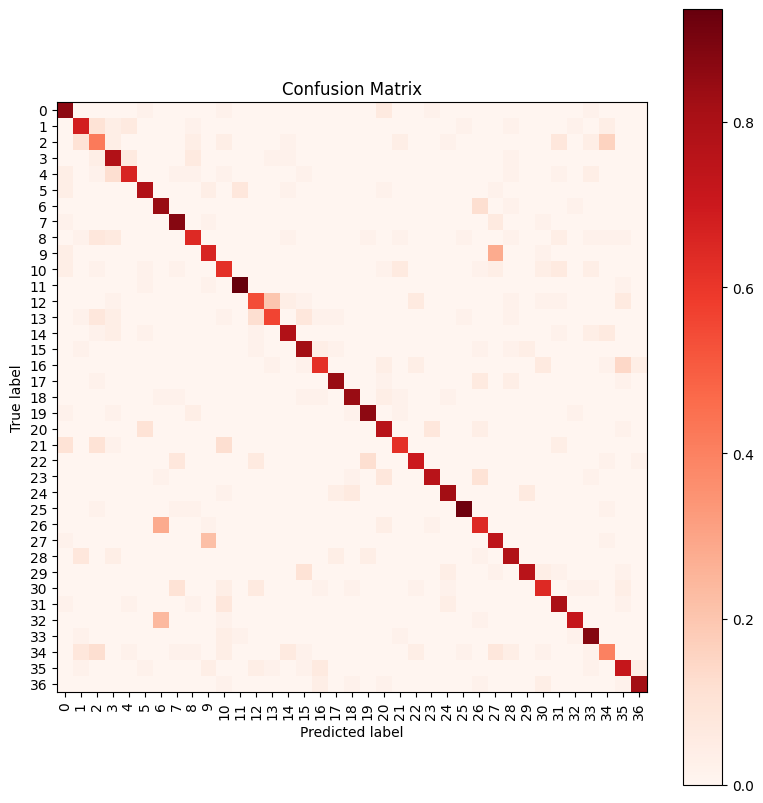

(<Figure size 814x814 with 2 Axes>,
 <Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>)

In [20]:
plot_cm_sklearn(model_resnet, test_dataset, normalize='true', include_values=False, save_path="results/confusion_matrix_test_dataset.png")